In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

In [4]:
data_path = r"E:\vs\module 2\Assignment 3 Email Classification with Naive Bayes\20_newsgroups"

categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.med",
    "talk.politics.misc"
]

In [5]:
file_path = os.path.join(data_path, "comp.graphics.txt")

with open(file_path, "r", encoding="latin-1") as file:
    text = file.read()

documents = re.split(r'(?m)(?=^From:\s)', text)
documents = [doc.strip() for doc in documents if doc.strip()]

len(documents)

2501

In [6]:
data = []

for category in categories:
    file_path = os.path.join(data_path, f"{category}.txt")

    with open(file_path, "r", encoding="latin-1") as file:
        text = file.read()

    documents = re.split(r'(?m)(?=^From:\s)', text)
    documents = [doc.strip() for doc in documents if doc.strip()]

    for doc in documents:
        data.append([category, doc])

df = pd.DataFrame(data, columns=["category", "text"])

df.shape

(8050, 2)

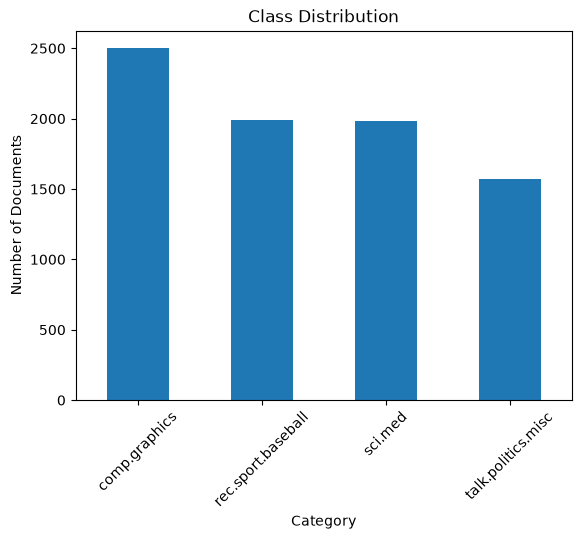

In [7]:
class_counts = df["category"].value_counts()

class_counts.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Number of Documents")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [8]:
df["document_length"] = df["text"].apply(lambda text: len(text.split()))

df["document_length"].describe()

count    8050.000000
mean      285.851677
std       607.694352
min         2.000000
25%        91.000000
50%       160.000000
75%       280.000000
max      9222.000000
Name: document_length, dtype: float64

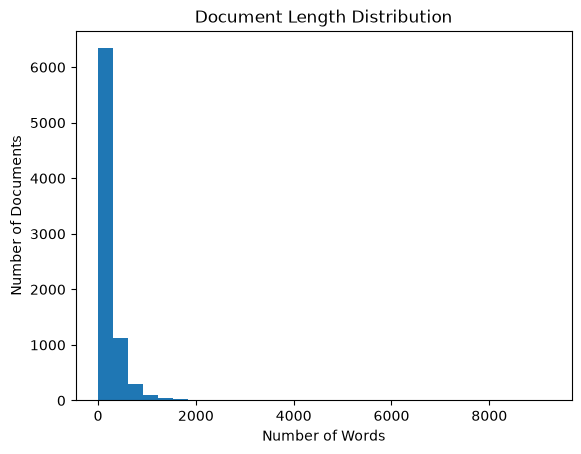

In [9]:
plt.hist(df["document_length"], bins=30)

plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")
plt.show()

In [10]:
for category in categories:
    sample = df[df["category"] == category].iloc[0]["text"]

    print(f"\n--- {category} ---")
    print(sample[:500])


--- comp.graphics ---
From: lipman@oasys.dt.navy.mil (Robert Lipman)
Subject: CALL FOR PRESENTATIONS: Navy SciViz/VR Seminar


			CALL FOR PRESENTATIONS
	
      NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR

			Tuesday, June 22, 1993

	    Carderock Division, Naval Surface Warfare Center
	      (formerly the David Taylor Research Center)
			  Bethesda, Maryland

SPONSOR: NESS (Navy Engineering Software System) is sponsoring a 
one-day Navy Scientific Visualization and Virtual Reality Seminar.  
The purpos

--- rec.sport.baseball ---
Newsgroup: rec.sport.baseball
document_id: 100521

--- sci.med ---
Newsgroup: sci.med
document_id: 57110

--- talk.politics.misc ---
Newsgroup: talk.politics.misc
document_id: 124146


In [11]:
stop_words = {
    "the", "is", "a", "an", "and", "or", "of", "to", "in",
    "on", "for", "with", "this", "that", "it", "as", "are",
    "was", "were", "be", "by", "from", "at", "which", "but",
    "not", "have", "has", "had", "they", "you", "he", "she",
    "we", "i", "their", "our", "your", "my"
}

In [12]:
def preprocess_text(text):
    text = text.lower()
    words = re.findall(r"\b[a-z]+\b", text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return words

In [13]:
df["tokens"] = df["text"].apply(preprocess_text)

In [14]:
vocabulary = set()

for tokens in df["tokens"]:
    vocabulary.update(tokens)

vocabulary_size = len(vocabulary)

vocabulary_size

37962

In [15]:
word_frequency = Counter()

for tokens in df["tokens"]:
    word_frequency.update(tokens)

word_frequency.most_common(20)

[('s', 16267),
 ('edu', 14793),
 ('t', 12438),
 ('if', 9882),
 ('can', 8551),
 ('subject', 8523),
 ('re', 7890),
 ('com', 7843),
 ('newsgroup', 7840),
 ('there', 7397),
 ('what', 6901),
 ('about', 6740),
 ('would', 6520),
 ('will', 6354),
 ('all', 6266),
 ('writes', 6099),
 ('do', 6010),
 ('one', 5840),
 ('article', 5583),
 ('so', 5531)]

In [16]:
total_documents = len(df)

class_priors = {}

for category in categories:
    class_count = len(df[df["category"] == category])
    class_priors[category] = class_count / total_documents

class_priors

{'comp.graphics': 0.3106832298136646,
 'rec.sport.baseball': 0.2475776397515528,
 'sci.med': 0.246583850931677,
 'talk.politics.misc': 0.1951552795031056}

In [17]:
class_word_counts = {}

for category in categories:
    counter = Counter()

    class_documents = df[
        df["category"] == category
    ]["tokens"]

    for tokens in class_documents:
        counter.update(tokens)

    class_word_counts[category] = counter

In [18]:
word_probabilities = {}

for category in categories:

    total_words = sum(class_word_counts[category].values())

    word_probabilities[category] = {}

    for word in vocabulary:
        count = class_word_counts[category][word]

        word_probabilities[category][word] = count / total_words

In [19]:
sample_words = ["computer", "baseball", "medical", "government"]

for word in sample_words:
    print(f"\nWord: {word}")

    for category in categories:
        probability = word_probabilities[category].get(word, 0)
        print(category, probability)


Word: computer
comp.graphics 0.00206371491513429
rec.sport.baseball 0.00012969748062643884
sci.med 0.00036730483785755617
talk.politics.misc 9.901391145455936e-05

Word: baseball
comp.graphics 0.0
rec.sport.baseball 0.010148827859018838
sci.med 2.0126292485345544e-05
talk.politics.misc 2.2503161694218037e-05

Word: medical
comp.graphics 0.0001552351927313404
rec.sport.baseball 1.2969748062643884e-05
sci.med 0.0025862285843669024
talk.politics.misc 0.0002250316169421804

Word: government
comp.graphics 3.424305722014861e-05
rec.sport.baseball 3.242437015660971e-05
sci.med 5.5347304334700247e-05
talk.politics.misc 0.0031144375784797765


In [20]:
np.random.seed(42)

indices = np.random.permutation(len(df))

train_end = int(0.60 * len(df))
val_end = int(0.80 * len(df))

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

train_df = df.iloc[train_indices].reset_index(drop=True)
val_df = df.iloc[val_indices].reset_index(drop=True)
test_df = df.iloc[test_indices].reset_index(drop=True)

In [21]:
vocabulary = set()

for tokens in train_df["tokens"]:
    vocabulary.update(tokens)

vocabulary = sorted(vocabulary)

word_to_index = {
    word: index
    for index, word in enumerate(vocabulary)
}

In [22]:
def create_bow(tokens, word_to_index):
    vector = np.zeros(len(word_to_index), dtype=int)

    for word in tokens:
        if word in word_to_index:
            vector[word_to_index[word]] += 1

    return vector

In [23]:
X_train = np.array([
    create_bow(tokens, word_to_index)
    for tokens in train_df["tokens"]
])

y_train = train_df["category"].values

In [24]:
class MultinomialNaiveBayes:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):

        self.classes = np.unique(y)

        self.class_log_prior = {}
        self.feature_log_prob = {}

        for category in self.classes:

            class_mask = (y == category)
            X_class = X[class_mask]

            class_count = X_class.shape[0]

            self.class_log_prior[category] = np.log(
                class_count / len(y)
            )

            word_counts = X_class.sum(axis=0)

            total_words = word_counts.sum()

            probabilities = (
                word_counts + self.alpha
            ) / (
                total_words +
                self.alpha * X.shape[1]
            )

            self.feature_log_prob[category] = np.log(
                probabilities
            )

    def predict(self, X):

        predictions = []

        for document in X:

            class_scores = {}

            for category in self.classes:

                score = self.class_log_prior[category]

                score += np.sum(
                    document *
                    self.feature_log_prob[category]
                )

                class_scores[category] = score

            prediction = max(
                class_scores,
                key=class_scores.get
            )

            predictions.append(prediction)

        return np.array(predictions)

In [25]:
X_val = np.array([
    create_bow(tokens, word_to_index)
    for tokens in val_df["tokens"]
])

y_val = val_df["category"].values

In [26]:
model = MultinomialNaiveBayes(alpha=1.0)

model.fit(X_train, y_train)

In [27]:
y_val_pred = model.predict(X_val)

In [28]:
accuracy = np.mean(y_val_pred == y_val)

accuracy

np.float64(0.9968944099378882)

In [29]:
alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0]

validation_accuracies = []

for alpha in alpha_values:

    model = MultinomialNaiveBayes(alpha=alpha)

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    accuracy = np.mean(predictions == y_val)

    validation_accuracies.append(accuracy)

In [30]:
alpha_results = pd.DataFrame({
    "Alpha": alpha_values,
    "Validation Accuracy": validation_accuracies
})

alpha_results

,Alpha,Validation Accuracy
0,0.1,0.998758
1,0.5,0.996894
2,1.0,0.996894
3,2.0,0.996894
4,5.0,0.993168


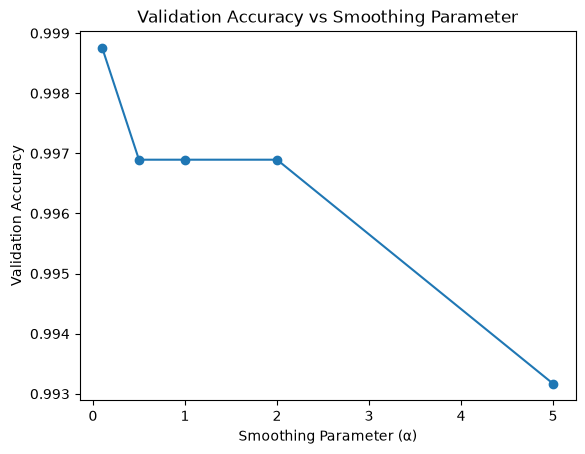

In [31]:
plt.plot(
    alpha_values,
    validation_accuracies,
    marker="o"
)

plt.xlabel("Smoothing Parameter (α)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Smoothing Parameter")
plt.show()

In [32]:
top_words = {}

for category in categories:

    word_counts = class_word_counts[category]

    top_words[category] = word_counts.most_common(10)

top_words

{'comp.graphics': [('graphics', 4683),
  ('edu', 4053),
  ('s', 3191),
  ('can', 3137),
  ('image', 2985),
  ('if', 2928),
  ('subject', 2683),
  ('comp', 2441),
  ('t', 2330),
  ('newsgroup', 2124)],
 'rec.sport.baseball': [('s', 4182),
  ('edu', 4140),
  ('t', 3136),
  ('baseball', 3130),
  ('sport', 2070),
  ('subject', 2054),
  ('rec', 2044),
  ('newsgroup', 2022),
  ('if', 2022),
  ('re', 1980)],
 'sci.med': [('edu', 3672),
  ('s', 3408),
  ('t', 2694),
  ('med', 2312),
  ('if', 2262),
  ('sci', 2254),
  ('com', 2222),
  ('can', 2154),
  ('subject', 2118),
  ('newsgroup', 2108)],
 'talk.politics.misc': [('s', 5486),
  ('t', 4278),
  ('edu', 2928),
  ('what', 2708),
  ('if', 2670),
  ('re', 2592),
  ('com', 2474),
  ('people', 2394),
  ('would', 2378),
  ('all', 2378)]}

In [33]:
for category in categories:

    print(f"\n{category}")

    for word, count in top_words[category]:
        print(word, count)


comp.graphics
graphics 4683
edu 4053
s 3191
can 3137
image 2985
if 2928
subject 2683
comp 2441
t 2330
newsgroup 2124

rec.sport.baseball
s 4182
edu 4140
t 3136
baseball 3130
sport 2070
subject 2054
rec 2044
newsgroup 2022
if 2022
re 1980

sci.med
edu 3672
s 3408
t 2694
med 2312
if 2262
sci 2254
com 2222
can 2154
subject 2118
newsgroup 2108

talk.politics.misc
s 5486
t 4278
edu 2928
what 2708
if 2670
re 2592
com 2474
people 2394
would 2378
all 2378


In [34]:
best_alpha_index = np.argmax(validation_accuracies)

best_alpha = alpha_values[best_alpha_index]

best_model = MultinomialNaiveBayes(alpha=best_alpha)

best_model.fit(X_train, y_train)

In [35]:
for category in categories:

    probabilities = best_model.feature_log_prob[category]

    top_indices = np.argsort(probabilities)[-10:][::-1]

    print(f"\n{category}")

    for index in top_indices:
        word = vocabulary[index]
        probability = np.exp(probabilities[index])

        print(word, probability)


comp.graphics
graphics 0.010336848246316742
edu 0.009067009740749773
s 0.007340029373178689
can 0.007194904972542466
image 0.006937309161413166
if 0.006672457130252052
subject 0.005935950797023206
t 0.005308287764271533
comp 0.005308287764271533
jpeg 0.0048112366920924615

rec.sport.baseball
s 0.01314627252384878
edu 0.012911819486427889
baseball 0.010043859075186363
t 0.00971671530204094
sport 0.006619754249597612
subject 0.0066143018533785245
rec 0.00656523028740671
if 0.0064616347592439905
newsgroup 0.006456182363024904
re 0.006303515268890371

sci.med
edu 0.009043469491671126
s 0.008874015513718329
t 0.006939760350744933
med 0.005770114600485379
sci 0.005753582505075352
if 0.0057163852904027895
com 0.0056254587656476285
can 0.005542798288597485
subject 0.005381610358349702
newsgroup 0.005303082905152063

talk.politics.misc
s 0.011784151885774988
t 0.009206218404595746
edu 0.006558011270414498
what 0.005914452553448663
if 0.005766508020812836
re 0.005729521887653883
com 0.005500207

In [36]:
X_test = np.array([
    create_bow(tokens, word_to_index)
    for tokens in test_df["tokens"]
])

y_test = test_df["category"].values

In [37]:
y_test_pred = best_model.predict(X_test)

In [38]:
test_accuracy = np.mean(y_test_pred == y_test)

test_accuracy

np.float64(0.9987577639751553)

In [39]:
class_accuracy = {}

for category in categories:

    mask = (y_test == category)

    class_accuracy[category] = np.mean(
        y_test_pred[mask] == y_test[mask]
    )

class_accuracy

{'comp.graphics': np.float64(0.9978540772532188),
 'rec.sport.baseball': np.float64(1.0),
 'sci.med': np.float64(0.9975845410628019),
 'talk.politics.misc': np.float64(1.0)}

In [40]:
confusion_matrix = pd.DataFrame(
    0,
    index=categories,
    columns=categories
)

for actual, predicted in zip(y_test, y_test_pred):
    confusion_matrix.loc[actual, predicted] += 1

confusion_matrix

,comp.graphics,rec.sport.baseball,sci.med,talk.politics.misc
comp.graphics,465,0,1,0
rec.sport.baseball,0,419,0,0
sci.med,1,0,413,0
talk.politics.misc,0,0,0,311


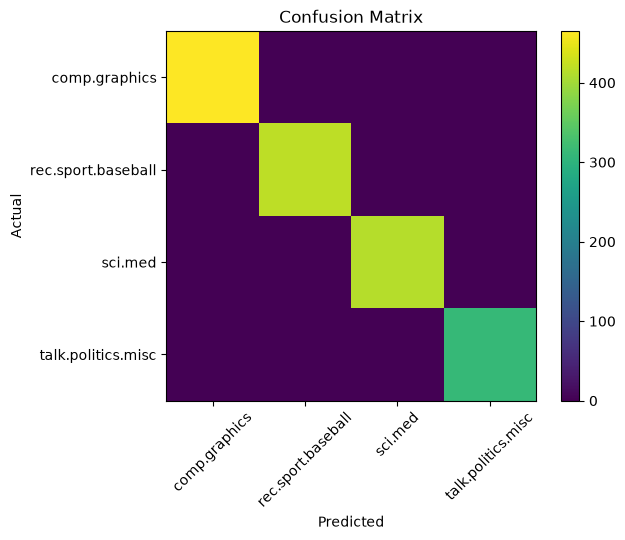

In [41]:
plt.imshow(confusion_matrix.values)

plt.xticks(
    range(len(categories)),
    categories,
    rotation=45
)

plt.yticks(
    range(len(categories)),
    categories
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()

In [42]:
random_baseline = 1 / len(categories)

random_baseline

0.25

In [43]:
comparison = pd.DataFrame({
    "Method": [
        "Random Baseline",
        "Naive Bayes"
    ],
    "Accuracy": [
        random_baseline,
        test_accuracy
    ]
})

comparison

,Method,Accuracy
0,Random Baseline,0.250000
1,Naive Bayes,0.998758


In [44]:
wrong_predictions = test_df[
    y_test != y_test_pred
].copy()

wrong_predictions["predicted_category"] = y_test_pred[
    y_test != y_test_pred
]

wrong_predictions[
    ["category", "predicted_category", "text"]
].head(10)

,category,predicted_category,text
280,sci.med,comp.graphics,From: ipj@unix.brighton.ac.uk ((( Fleg Softwar...
953,comp.graphics,sci.med,From: torb@mack.uit.no (Tor Berger)\nSubject: ...


In [45]:
error_pairs = pd.DataFrame({
    "Actual": y_test[y_test != y_test_pred],
    "Predicted": y_test_pred[y_test != y_test_pred]
})

error_pairs.value_counts()

Actual         Predicted    
sci.med        comp.graphics    1
comp.graphics  sci.med          1
Name: count, dtype: int64

In [46]:
rare_words = {
    word: count
    for word, count in word_frequency.items()
    if count <= 2
}
 
len(rare_words)

11312

In [47]:
print("Best Alpha:", best_alpha)
print("Validation Accuracy:", validation_accuracies[best_alpha_index])
print("Test Accuracy:", test_accuracy)
print("Random Baseline:", random_baseline)

Best Alpha: 0.1
Validation Accuracy: 0.9987577639751553
Test Accuracy: 0.9987577639751553
Random Baseline: 0.25
